# Review Integrity Analysis

Exploratory analysis behind the three models in this repository: what critic reviews say,
what score their text implies, and which reviews look anomalous.

**This notebook is the analysis layer, not the pipeline.** Feature engineering lives in the
dbt project (`dbt/models/`) and the models live in the `rotten_review` package. Here we read
the finished mart, fit the models on the folds dbt assigned, and interpret the results.

### Running it

| Mode | Trigger | Data |
|---|---|---|
| **sample** (default) | no warehouse present | dbt builds the synthetic seeds into a temp DuckDB |
| **full** | `data/warehouse.duckdb` exists | the real Rotten Tomatoes + IMDB data |

Sample mode needs no Kaggle credentials and runs in under a minute — it is what CI executes
on every push. For the real numbers run `make ingest && make dbt` first, then re-run this
notebook top to bottom.

> Check the mode printed by the first cell before reading any number below. In **sample mode**
> the figures describe generated data (`scripts/generate_seeds.py`) and are artefacts of the
> generator, not findings about real critics — those cells are marked `[sample mode]`. In
> **full mode** they describe the real Rotten Tomatoes dataset.

The original single-file course notebook is preserved unchanged at
`notebooks/original/EDT_Rotten_Review_Model.ipynb`; `AUDIT.md` records what this rework
changed and why.

## 0. Setup

In [1]:
import os
import subprocess
import sys
import tempfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rotten_review import config, features
from rotten_review.models import score_regressor, sentiment
from rotten_review.models.anomaly import AnomalyDetector, build_embedder
from rotten_review.preprocessing import clean_text

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DBT_DIR = config.REPO_ROOT / "dbt"


def resolve_warehouse() -> tuple[Path, str]:
    """Use the real warehouse if it exists, otherwise build the seeds into a temp DuckDB."""
    if config.WAREHOUSE_PATH.exists():
        return config.WAREHOUSE_PATH, "full"

    db_path = Path(tempfile.mkdtemp(prefix="rotten-review-sample-")) / "sample.duckdb"
    result = subprocess.run(
        [sys.executable, "-m", "dbt.cli.main", "build",
         "--target", "test", "--profiles-dir", str(DBT_DIR)],
        cwd=DBT_DIR,
        env={**os.environ, "ROTTEN_REVIEW_DB": str(db_path)},
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stdout[-3000:] + result.stderr[-2000:])
    return db_path, "sample"


WAREHOUSE, MODE = resolve_warehouse()


def note(message: str) -> None:
    """Print a caveat that only applies when running against generated data."""
    if MODE == "sample":
        print(f"[sample mode] {message}")


print(f"mode = {MODE}\nwarehouse = {WAREHOUSE}")

mode = full
warehouse = D:\Projects\rotten-review-pipeline\data\warehouse.duckdb


In [2]:
def query(sql: str) -> pd.DataFrame:
    con = duckdb.connect(str(WAREHOUSE), read_only=True)
    try:
        return con.execute(sql).df()
    finally:
        con.close()


reviews = query("SELECT * FROM fct_review_features")
reviewers = query("SELECT * FROM dim_reviewers")

print(f"{len(reviews):,} reviews | {len(reviewers):,} critics "
      f"| {reviews['rotten_tomatoes_link'].nunique():,} films")
print(f"date range: {reviews['review_date'].min()} -> {reviews['review_date'].max()}")
reviews[["critic_name", "movie_title", "review_date", "score_10", "review_type_encoded"]].head()

249,180 reviews | 3,311 critics | 15,938 films
date range: 1927-08-12 00:00:00 -> 2020-10-27 00:00:00


,critic_name,movie_title,review_date,score_10,review_type_encoded
0,Geoff Pevere,The Last Days On Mars,2013-12-06,5,0
1,Mick LaSalle,The Last Days On Mars,2013-12-12,3,0
2,Tim Robey,The Last Face,2016-05-20,2,0
3,David Sexton,The Last Face,2016-05-22,4,0
4,Claudia Puig,The Last Face,2017-07-28,<NA>,0


## 1. Data quality

Four things decide how much data survives to modelling: the top-critic filter, whether the
review is attributed to a named critic, whether it is a duplicate of a row already counted,
and whether its score string can be parsed at all. Rotten Tomatoes lets critics write the
score in whatever notation they like — `3/5`, `B+`, `85%`, `7.5` — so parsing coverage is a
real constraint, not a formality.

Timing is the other constraint, and it is the one that bites hardest. Rotten Tomatoes imported
long-serving critics' back catalogues under a single timestamp, and it uses `1800-01-01` as a
placeholder date. Both are handled in dbt — sentinel dates are nulled, same-day import batches
are flagged and kept out of the burst window — but they cost real coverage, so the table above
reports how many reviews still carry usable timing features.

The duplicate and attribution filters are not cosmetic. The source dump contains exact
duplicate rows; left in, a critic appears to publish twice as often as they do, which is
precisely the burst signal Model 3 keys on, and the same review text can land on both sides
of the train/holdout split. Rows without a critic name collapse into a single pseudo-critic
whose "history" is a blend of hundreds of unrelated people.

In [3]:
# how many rows each staging filter removes, in order
funnel = query("""
    WITH raw AS (SELECT * FROM {source_table}),
    top_critics AS (
        SELECT * FROM raw
        WHERE top_critic AND review_content IS NOT NULL AND trim(review_content) <> ''
    ),
    attributed AS (
        SELECT * FROM top_critics
        WHERE critic_name IS NOT NULL AND trim(critic_name) <> ''
    )
    SELECT
        (SELECT count(*) FROM raw)                                   AS raw_rows,
        (SELECT count(*) FROM top_critics)                           AS after_top_critic_filter,
        (SELECT count(*) FROM attributed)                            AS after_attribution_filter,
        (SELECT count(*) FROM stg_rt_reviews)                        AS after_deduplication
""".format(source_table="sample_rt_reviews" if MODE == "sample" else "raw_rt_reviews"))

stage_names = list(funnel.columns)
counts = funnel.iloc[0].tolist()
pd.DataFrame({
    "stage": stage_names,
    "rows": counts,
    "removed": [0] + [counts[i - 1] - counts[i] for i in range(1, len(counts))],
})

,stage,rows,removed
0,raw_rows,1130017,0
1,after_top_critic_filter,280638,849379
2,after_attribution_filter,278337,2301
3,after_deduplication,249180,29157


In [4]:
# how much of the timing signal the source data actually supports
timing_quality = query("""
    SELECT
        count(*)                                              AS reviews,
        count(review_date)                                    AS with_usable_date,
        sum(CASE WHEN is_backfill_batch THEN 1 ELSE 0 END)    AS in_archive_backfill,
        count(reviewer_reviews_last_7d)                       AS with_burst_features
    FROM fct_review_features
""")
timing_quality

,reviews,with_usable_date,in_archive_backfill,with_burst_features
0,249180,249169,22665.0,226504


In [5]:
parse_stats = query("""
    SELECT
        count(*)                                             AS reviews,
        count(score_100)                                     AS parsed_scores,
        count(*) - count(score_100)                          AS unparsed,
        round(100.0 * count(score_100) / count(*), 1)        AS parsed_pct,
        count(review_type_encoded)                           AS has_fresh_rotten_label
    FROM stg_rt_reviews
""")
parse_stats

,reviews,parsed_scores,unparsed,parsed_pct,has_fresh_rotten_label
0,249180,159092,90088,63.8,249180


In [6]:
missing = reviews.isna().mean().mul(100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
print("columns with missing values (% of rows):")
print(missing.to_string() if len(missing) else "none")

print("\nrows usable per model:")
print(f"  Model 1 (needs fresh/rotten label): {reviews['review_type_encoded'].notna().sum():,}")
print(f"  Model 2 (needs a parsed score):     {reviews['score_10'].notna().sum():,}")
print(f"  Model 3 (needs score + behaviour):  "
      f"{reviews.dropna(subset=['score_10', 'critic_std_score_10']).shape[0]:,}")

columns with missing values (% of rows):
score_100                   36.2
score_10                    36.2
z_score_critic              36.2
publisher_z_score           36.2
consensus_diff              36.2
critic_mean_score_10        11.6
reviewer_reviews_last_7d     9.1
reviewer_burst_ratio_7d      9.1
publisher_mean_score_10      2.1
days_since_release           1.9
is_early_review              1.9
production_company           1.0
tomatometer_rating           0.1

rows usable per model:
  Model 1 (needs fresh/rotten label): 249,180
  Model 2 (needs a parsed score):     159,092
  Model 3 (needs score + behaviour):  159,092


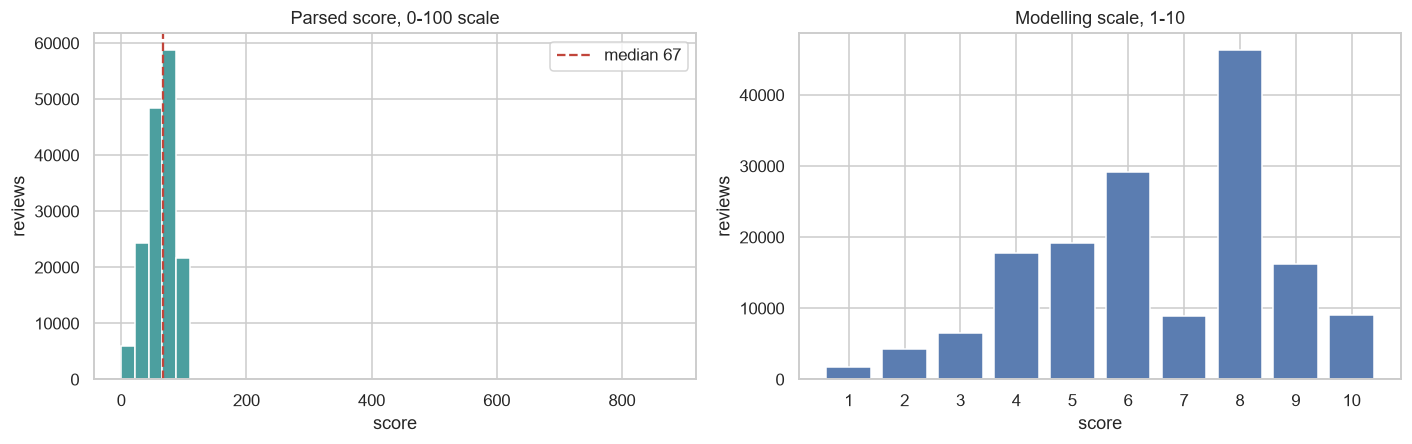

count    159092.0
mean         6.54
std          2.09
min           1.0
25%           5.0
50%           7.0
75%           8.0
max          10.0


In [7]:
scored = reviews.dropna(subset=["score_10"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(scored["score_100"], bins=40, color="#4C9F9F", edgecolor="white")
axes[0].axvline(scored["score_100"].median(), color="#C1453B", ls="--",
                label=f"median {scored['score_100'].median():.0f}")
axes[0].set(title="Parsed score, 0-100 scale", xlabel="score", ylabel="reviews")
axes[0].legend()

counts = scored["score_10"].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="#5B7DB1", edgecolor="white")
axes[1].set(title="Modelling scale, 1-10", xlabel="score", ylabel="reviews",
            xticks=range(1, 11))

fig.tight_layout()
plt.show()

print(scored["score_10"].describe().round(2).to_string())

Note the shape: critic scores are strongly left-skewed — most reviews sit in the upper half of
the scale. That matters later, because a regressor that always predicts "slightly above
average" already scores respectably on MAE. Any claim about Model 2 has to be read against
that baseline.

In [8]:
mean_baseline = np.full(len(scored), scored["score_10"].mean())
mae_baseline = np.abs(scored["score_10"] - mean_baseline).mean()
print(f"MAE of always predicting the mean score: {mae_baseline:.3f}")

MAE of always predicting the mean score: 1.793


## 2. Timing and reviewer behaviour

The behavioural side of fake-review detection rests on two ideas: reviews that appear
unusually early relative to a film's release, and critics who publish in bursts. Both are
computed in dbt (`int_burst_activity`) with a trailing 7-day window function.

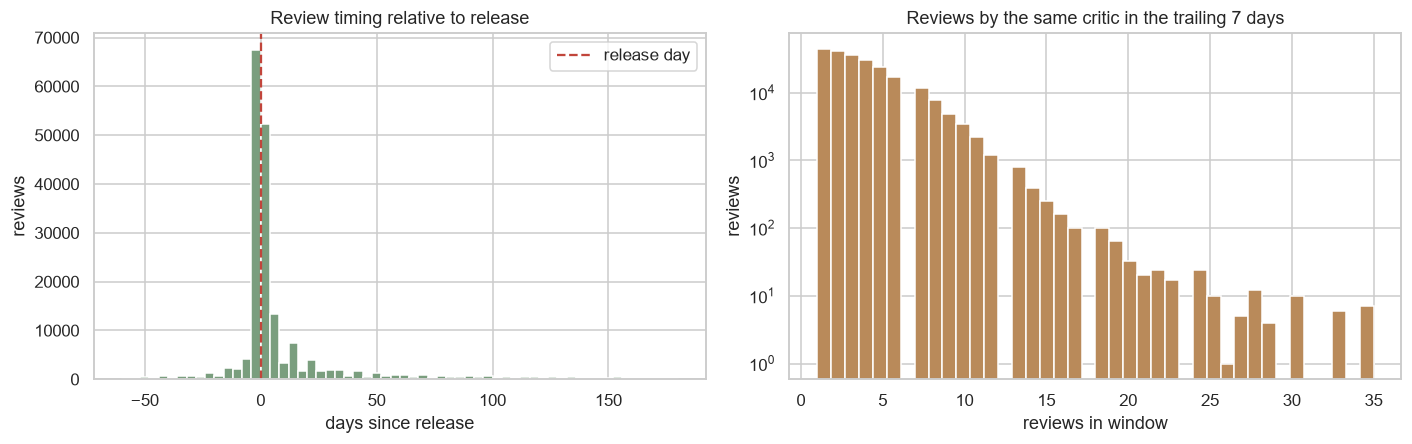

published within a week of release: 64.7%
flagged as bursty by the dbt rule:  3.7%


In [9]:
timing = reviews.dropna(subset=["days_since_release"])
window = timing[timing["days_since_release"].between(-60, 180)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(window["days_since_release"], bins=60, color="#7A9E7E", edgecolor="white")
axes[0].axvline(0, color="#C1453B", ls="--", label="release day")
axes[0].set(title="Review timing relative to release", xlabel="days since release",
            ylabel="reviews")
axes[0].legend()

axes[1].hist(reviews["reviewer_reviews_last_7d"].dropna(), bins=40,
             color="#B98A5A", edgecolor="white")
axes[1].set(title="Reviews by the same critic in the trailing 7 days",
            xlabel="reviews in window", ylabel="reviews", yscale="log")

fig.tight_layout()
plt.show()

early = (timing["days_since_release"] < 7).mean()
print(f"published within a week of release: {early:.1%}")
print(f"flagged as bursty by the dbt rule:  {reviews['is_reviewer_burst_any'].mean():.1%}")

In [10]:
# threshold sensitivity: the ">10 reviews in 7 days" cutoff is a judgement call,
# so it is worth seeing how much the flag rate depends on it
rows = []
for threshold in [5, 8, 10, 15, 20, 30]:
    flagged = reviews["reviewer_reviews_last_7d"] > threshold
    rows.append({
        "threshold": threshold,
        "reviews_flagged": int(flagged.sum()),
        "pct_of_reviews": round(100 * flagged.mean(), 2),
        "critics_flagged": int(reviews.loc[flagged, "critic_name"].nunique()),
    })
pd.DataFrame(rows)

,threshold,reviews_flagged,pct_of_reviews,critics_flagged
0,5,50588,22.33,429
1,8,13738,6.07,210
2,10,5453,2.41,135
3,15,598,0.26,37
4,20,140,0.06,14
5,30,13,0.01,2


In [11]:
top_burst = reviewers.nlargest(10, "max_reviews_in_7d")[
    ["critic_name", "review_count", "max_reviews_in_7d", "burst_share", "positive_ratio"]
]
top_burst.round(3)

,critic_name,review_count,max_reviews_in_7d,burst_share,positive_ratio
1234,John Leonard,51,35,0.627,0.765
3113,Variety Staff,1524,33,0.196,0.678
1872,Noel Murray,1007,27,0.031,0.673
1184,Brian Tallerico,566,25,0.062,0.595
1892,David Thomson,102,24,0.216,0.578
2259,Dave Kehr,1181,23,0.077,0.555
3150,Gene Siskel,308,23,0.081,0.584
448,Gary Arnold,138,22,0.188,0.406
606,David Ansen,689,22,0.046,0.730
2684,Peter Bradshaw,3368,22,0.234,0.624


## 3. Model 1 — sentiment

Bag-of-words + logistic regression, trained on IMDB plus the RT reviews dbt assigned to the
`train` fold, and evaluated only on the `holdout` fold. The fold is a hash of `review_id`, so
a review lands in the same side of the split on every rebuild — the model never sees the rows
it is later scored on.

In [12]:
corpus = query("SELECT text, label, source, split FROM stg_sentiment_corpus")
corpus["text"] = corpus["text"].map(clean_text)
corpus = corpus[corpus["text"].str.strip() != ""]

train_df = corpus[corpus["split"] == "train"]
holdout_df = corpus[corpus["split"] == "holdout"]

print(corpus.groupby(["source", "split"]).size().to_string())
print(f"\ntrain {len(train_df):,} | holdout {len(holdout_df):,}")

sentiment_model = sentiment.fit(train_df["text"], train_df["label"])
sentiment_metrics = sentiment.evaluate(sentiment_model, holdout_df["text"], holdout_df["label"])
print(f"\nholdout accuracy: {sentiment_metrics['accuracy']:.3f} "
      f"(n={sentiment_metrics['n_eval']:,})")
note("generated reviews are drawn from a small template pool, so this accuracy is a property "
     "of the generator, not of the model.")

source           split  
imdb             train       50000
rotten_tomatoes  holdout     49594
                 train      199582

train 249,582 | holdout 49,594



holdout accuracy: 0.774 (n=49,594)


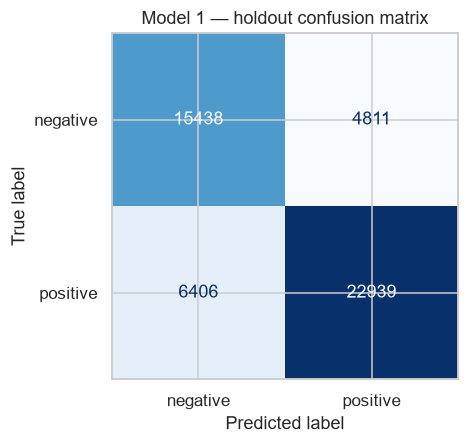

,precision,recall,f1-score,support
-1,0.707,0.762,0.734,20249.0
1,0.827,0.782,0.804,29345.0


In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ConfusionMatrixDisplay.from_estimator(
    sentiment_model, holdout_df["text"], holdout_df["label"],
    display_labels=["negative", "positive"], colorbar=False, cmap="Blues", ax=ax,
)
ax.set_title("Model 1 — holdout confusion matrix")
fig.tight_layout()
plt.show()

report = pd.DataFrame(sentiment_metrics["report"]).T
report.loc[["-1", "1"], ["precision", "recall", "f1-score", "support"]].round(3)

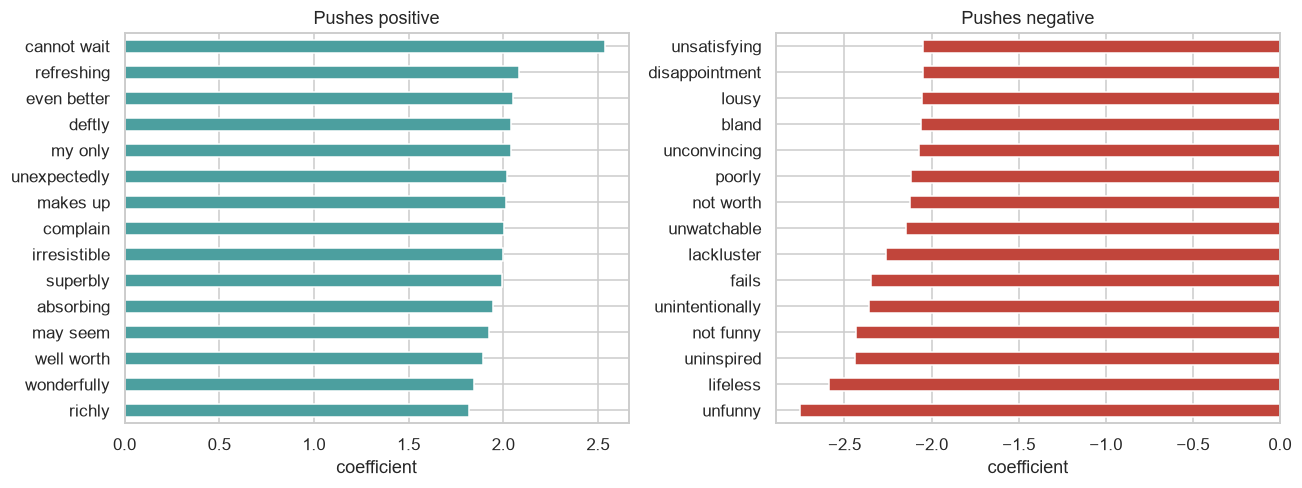

In [14]:
# what the model actually keys on
vec = sentiment_model.named_steps["vectorizer"]
coefs = pd.Series(sentiment_model.named_steps["clf"].coef_[0], index=vec.get_feature_names_out())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (title, series, colour) in zip(
    axes,
    [("Pushes positive", coefs.nlargest(15), "#4C9F9F"),
     ("Pushes negative", coefs.nsmallest(15), "#C1453B")],
    strict=True,
):
    series.sort_values().plot.barh(ax=ax, color=colour)
    ax.set(title=title, xlabel="coefficient")
fig.tight_layout()
plt.show()

## 4. Model 2 — the score implied by the text

Ridge regression on TF-IDF. This is the model whose residual (declared score minus implied
score) becomes an input to the anomaly detector, so its honesty matters more than its headline
accuracy.

### The leakage the original notebook had

The original pipeline cleaned review text with a function that stripped punctuation but kept
digits. A critic who writes *"Verdict: 3/5"* in the body therefore contributed the token `35`
to the feature matrix — the target, sitting in the input. The package's `clean_text` removes
digits.

The effect is diluted across the full holdout (most reviews never state a score), so the cells
below report it twice: over everything, and over just the rows the shortcut can actually act
on. The second column is the honest measure of the leak.

In [15]:
scored = reviews.dropna(subset=["score_10"]).copy()
scored["text_no_digits"] = scored["review_text"].map(clean_text)          # package behaviour
scored["text_with_digits"] = (                                            # original behaviour
    scored["review_text"].str.lower().str.replace(r"[^\w\s]", " ", regex=True)
                          .str.replace(r"\s+", " ", regex=True).str.strip()
)
scored = scored[scored["text_no_digits"].str.strip() != ""]

# reviews whose body text spells out a numeric score - the rows the shortcut applies to
SCORE_IN_TEXT = r"\d+\s*(?:/|out of)\s*\d+|\b\d{1,3}\s*%"
scored["states_score_in_text"] = scored["review_text"].str.contains(
    SCORE_IN_TEXT, regex=True, na=False
)

train_s = scored[scored["split"] == "train"]
hold_s = scored[scored["split"] == "holdout"]
hold_leaky = hold_s[hold_s["states_score_in_text"]]

print(f"reviews stating a numeric score in the body: {scored['states_score_in_text'].mean():.1%}"
      f"  (holdout rows affected: {len(hold_leaky)} of {len(hold_s)})")

reviews stating a numeric score in the body: 0.2%  (holdout rows affected: 41 of 31649)


In [16]:
rows = []
for label, column in [("digits removed (this repo)", "text_no_digits"),
                      ("digits kept (original)", "text_with_digits")]:
    model = score_regressor.fit(train_s[column], train_s["score_10"].astype(float))
    overall = score_regressor.evaluate(model, hold_s[column], hold_s["score_10"].astype(float))
    row = {"variant": label, "mae_all": overall["mae"], "r2_all": overall["r2"]}
    if len(hold_leaky) >= 10:
        affected = score_regressor.evaluate(
            model, hold_leaky[column], hold_leaky["score_10"].astype(float)
        )
        row["mae_on_affected_rows"] = affected["mae"]
    rows.append(row)
    if column == "text_no_digits":
        score_model = model

comparison = pd.DataFrame(rows).set_index("variant").round(3)
comparison

,mae_all,r2_all,mae_on_affected_rows
variant,,,
digits removed (this repo),1.364,0.336,1.319
digits kept (original),1.360,0.338,1.377


In [17]:
if "mae_on_affected_rows" in comparison.columns:
    gap = (comparison.loc["digits removed (this repo)", "mae_on_affected_rows"]
           - comparison.loc["digits kept (original)", "mae_on_affected_rows"])
    print(f"MAE gap on rows that state their score in text: {gap:+.3f} points")
    print("A positive gap means keeping digits looked better purely by reading the answer "
          "off the input.")
else:
    print("Too few affected holdout rows to isolate the effect.")

note("synthetic review text is far more separable than real critic prose, so both variants "
     "score better here than they will on the real dataset, and the gap between them is "
     "compressed. Re-run in full mode for the real magnitude.")

MAE gap on rows that state their score in text: -0.058 points
A positive gap means keeping digits looked better purely by reading the answer off the input.


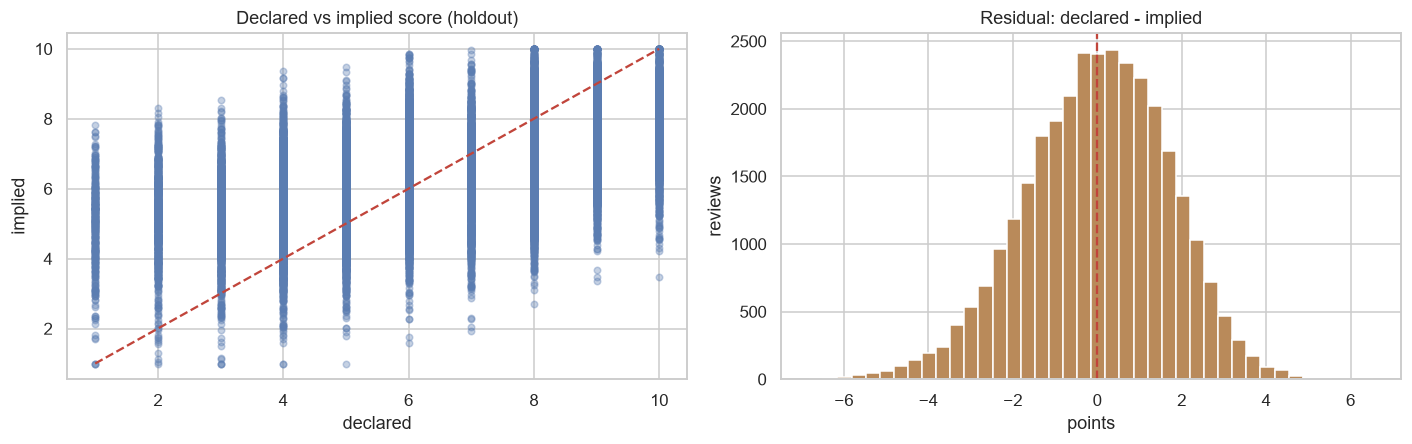

residual mean -0.002 | sd 1.706


In [18]:
preds = np.clip(score_model.predict(hold_s["text_no_digits"]), 1, 10)
residuals = hold_s["score_10"].astype(float) - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(hold_s["score_10"], preds, alpha=0.35, s=18, color="#5B7DB1")
axes[0].plot([1, 10], [1, 10], color="#C1453B", ls="--")
axes[0].set(title="Declared vs implied score (holdout)", xlabel="declared", ylabel="implied")

axes[1].hist(residuals, bins=40, color="#B98A5A", edgecolor="white")
axes[1].axvline(0, color="#C1453B", ls="--")
axes[1].set(title="Residual: declared - implied", xlabel="points", ylabel="reviews")
fig.tight_layout()
plt.show()

print(f"residual mean {residuals.mean():+.3f} | sd {residuals.std():.3f}")

The regressor is deliberately weak on purpose-built signal: it is a linear model over word
counts, and it compresses toward the mean. That is acceptable here because Model 3 does not
consume the prediction — it consumes the *residual*, and a systematically compressed
prediction still ranks reviews correctly by how far their text sits from their score.

## 5. Bias score and Model 3 — anomaly detection

`bias_score` combines four standardised signals with fixed weights (0.4 / 0.2 / 0.3 / 0.1):
the critic's z-score against their own history, the text/score residual, the distance from the
tomatometer consensus, and the distance from the publication's typical scoring. The Isolation
Forest then works on those behavioural features plus a dense text representation.

There is **no ground-truth fake label** in this data. Everything below ranks reviews by how
unusual they are; it does not measure detection accuracy, and it cannot.

In [19]:
model_input = reviews.dropna(subset=["score_10", "critic_std_score_10"]).copy()
model_input = features.add_model_features(model_input, sentiment_model, score_model)
model_input = model_input[model_input["text_cleaned"].str.strip() != ""]

print(f"rows into Model 3: {len(model_input):,}")
model_input[["z_score_critic", "sentiment_diff", "consensus_diff",
             "publisher_z_score", "bias_score"]].describe().round(2)

rows into Model 3: 159,090


,z_score_critic,sentiment_diff,consensus_diff,publisher_z_score,bias_score
count,159090.00,159090.0,159090.00,159090.00,159090.00
mean,0.00,1.2,1.73,0.83,4.57
std,0.99,0.91,1.42,0.55,0.81
min,-6.28,0.0,0.00,0.00,1.00
25%,-0.77,0.49,0.60,0.39,3.99
50%,0.04,1.02,1.40,0.82,4.50
75%,0.79,1.71,2.50,1.10,5.04
max,3.16,6.82,10.00,5.82,10.00


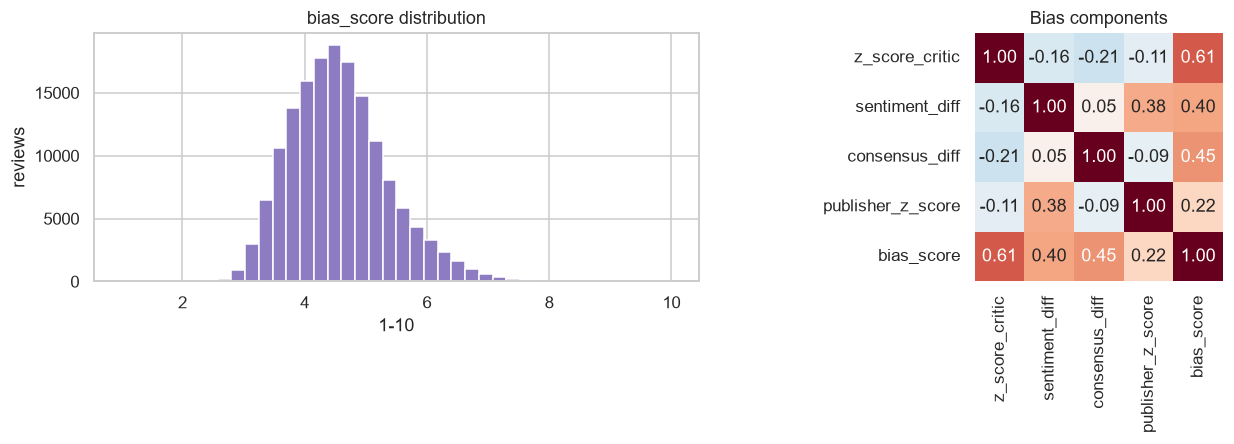

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(model_input["bias_score"], bins=40, color="#8E7CC3", edgecolor="white")
axes[0].set(title="bias_score distribution", xlabel="1-10", ylabel="reviews")

corr = model_input[[
    "z_score_critic", "sentiment_diff", "consensus_diff", "publisher_z_score", "bias_score"
]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            cbar=False, square=True)
axes[1].set_title("Bias components")
fig.tight_layout()
plt.show()

`bias_score` correlates strongly with its own inputs — by construction, since it is their
weighted sum. Feeding both the components *and* their combination into the Isolation Forest
therefore double-counts those signals. The original notebook did exactly that; it is kept here
so the effect stays visible and measurable, but it is a known weakness, not a design choice.

In [21]:
# "sbert" swaps in all-MiniLM-L6-v2 + UMAP; needs the `embeddings` extra
detector = AnomalyDetector(embedder=build_embedder("tfidf"))

# fit_score keeps one fitted embedder for both steps — scoring with a freshly
# fitted embedder would place these reviews in a different latent space than
# the forest was trained in
fit_info, scores = detector.fit_score(model_input, model_input["text_cleaned"].tolist())
flagged = model_input.join(scores)

print(f"{fit_info['flagged']:,} of {fit_info['n_reviews']:,} reviews flagged "
      f"({fit_info['flagged_pct']:.1f}%) across {fit_info['n_features']} features")
print("5% is the contamination parameter, i.e. an assumption, not a measurement.")
note("the generator plants one bursty critic and a batch of text/score mismatches, so the "
     "flagged profile below mostly recovers what was deliberately put in.")

7,955 of 159,090 reviews flagged (5.0%) across 22 features
5% is the contamination parameter, i.e. an assumption, not a measurement.


In [22]:
comparison_cols = [
    "reviewer_reviews_last_7d", "positive_ratio", "days_since_release",
    "word_count", "z_score_critic", "consensus_diff", "bias_score",
]
profile = (
    flagged.groupby("is_fake_review")[comparison_cols]
    .mean().T.rename(columns={0: "not flagged", 1: "flagged"})
)
profile["difference"] = profile["flagged"] - profile["not flagged"]
profile.round(2)

is_fake_review,not flagged,flagged,difference
reviewer_reviews_last_7d,4.068732,4.064123,-0.004609
positive_ratio,0.590862,0.601029,0.010167
days_since_release,411.24336,3516.265461,3105.022101
word_count,21.624548,22.00176,0.377212
z_score_critic,0.007804,-0.148189,-0.155992
consensus_diff,1.710836,2.188837,0.478001
bias_score,4.543059,5.089894,0.546834


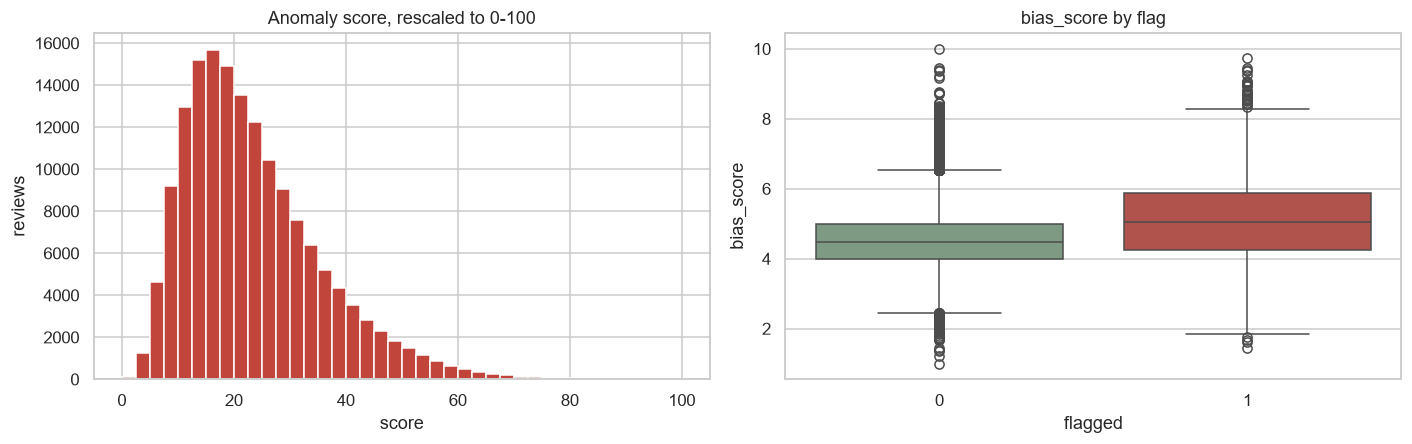

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(flagged["fraud_probability"], bins=40, color="#C1453B", edgecolor="white")
axes[0].set(title="Anomaly score, rescaled to 0-100", xlabel="score", ylabel="reviews")

sns.boxplot(data=flagged, x="is_fake_review", y="bias_score", ax=axes[1],
            palette=["#7A9E7E", "#C1453B"], hue="is_fake_review", legend=False)
axes[1].set(title="bias_score by flag", xlabel="flagged", ylabel="bias_score")
fig.tight_layout()
plt.show()

In [24]:
top = flagged.nlargest(8, "fraud_probability")[
    ["critic_name", "movie_title", "score_10", "predicted_score",
     "reviewer_reviews_last_7d", "bias_score", "fraud_probability"]
]
top.round(2).reset_index(drop=True)

,critic_name,movie_title,score_10,predicted_score,reviewer_reviews_last_7d,bias_score,fraud_probability
0,Kayt Bochenski and Nelly Twort,What to Expect When You're Expecting,6,6.99,1,4.99,100.00
1,Kate Cameron,From Here to Eternity,10,5.14,12,6.18,96.86
2,Kate Cameron,Miracle on 34th Street,10,9.28,1,4.50,96.15
3,Harper Barnes,The Fast and the Furious: Tokyo Drift,8,5.17,1,6.17,93.64
4,Samantha Highfill,Mother's Day,6,7.25,1,6.16,93.48
5,Bob Heisler,Strangeland,1,6.17,3,5.46,93.11
6,Victor Godinez,Doom,8,6.83,1,5.88,92.09
7,Stephen Whitty,Bravetown,1,6.15,4,4.43,91.65


In [25]:
# which critics accumulate the most flags, normalised by how much they publish
by_critic = (
    flagged.groupby("critic_name")
    .agg(reviews=("review_id", "count"),
         flagged=("is_fake_review", "sum"),
         mean_fraud_probability=("fraud_probability", "mean"))
)
by_critic["flag_rate"] = (by_critic["flagged"] / by_critic["reviews"]).round(3)
by_critic[by_critic["reviews"] >= 5].nlargest(10, "flag_rate").round(2)

,reviews,flagged,mean_fraud_probability,flag_rate
critic_name,,,,
Andre Sennwald,8,8,60.05,1.00
Frank S. Nugent,17,17,63.32,1.00
Kate Cameron,18,18,71.71,1.00
Thomas M. Pryor,5,5,61.10,1.00
Wanda Hale,9,9,66.61,1.00
Martin Chilton,17,16,55.45,0.94
Sebastian Doggart,7,6,55.86,0.86
Joseph Gelmis,6,5,55.72,0.83
Rick Kogan,6,5,52.35,0.83


In [26]:
unseen = model_input.tail(3).copy()
unseen_scores = detector.score(unseen, unseen["text_cleaned"].tolist())
print("scoring three rows through the fitted detector, no refit:")
print(unseen_scores.round(3).to_string())

scoring three rows through the fitted detector, no refit:
        anomaly_score  is_fake_review  fraud_probability
249177          0.065               0             25.235
249178          0.038               0             34.192
249179          0.010               0             43.657


## 6. Findings and limitations

**What the data supports**

- Score parsing is the binding constraint on Models 2 and 3: roughly a third of top-critic
  reviews carry a score this pipeline cannot parse, and those rows drop out. The coverage
  figure in section 1 is the number to quote, not the raw review count.
- The score distribution is left-skewed, so the mean-prediction baseline in section 1 is the
  bar Model 2 has to clear. It clears it, but by a margin worth stating plainly rather than
  quoting R² alone.
- Removing digits from review text is the right default, and the measurement in section 4 says
  it costs essentially nothing here: only a fraction of a percent of critic reviews restate
  their score in prose. The leak is real as a mechanism and immaterial on this dataset. That is
  a negative result, and it is reported as one.

**What the data does not support**

- *No ground truth.* Model 3 ranks reviews by unusualness. Calling the top 5% "fake" is a
  labelling convention driven by the `contamination` parameter, and nothing here validates it.
- *The anomaly model is dominated by age, not behaviour.* Compare `days_since_release` between
  the flagged and unflagged groups in section 5: flagged reviews are overwhelmingly ones
  written long after their film's release. Those are retrospectives and archival entries, not
  suspicious activity. Read the flagged critic list and the point becomes obvious — it is
  populated by newspaper critics active decades ago. Model 3 has found the largest axis of
  variation in the dataset, and that axis is the archive.
- *Circular features.* `bias_score` is a weighted sum of four features that are themselves
  inputs to the same forest, so those signals are counted twice.
- *Consensus is a proxy.* `consensus_diff` compares a critic's 1-10 score against
  `tomatometer_rating / 10`. The tomatometer is the share of positive reviews, not an average
  score, so the two are not on the same scale — the feature carries signal but the units are a
  fiction.
- *In-sample sentiment features.* Model 1 is evaluated only on the holdout fold, but the
  sentiment feature fed to Model 3 is computed for every review, so for train-fold rows it is
  an in-sample prediction.

**The obvious next step**

Restrict the anomaly analysis to first-run reviews — say `days_since_release` between -30 and
365 — and re-fit. That removes the archival axis and forces the forest to work on the
behavioural signals it was built for. It is a one-line filter on `model_input`, deliberately
left out of this notebook so the archival effect stays visible rather than quietly excluded.

Beyond that: labelled data. Even a few hundred hand-adjudicated reviews would turn every
ranking above into something measurable, and precision@k on a human-reviewed sample is the
smallest useful version of that.